# **AAI 540 - EDA Notebook**

- Loads the combined feature dataset
- Checks data quality (shape, duplicates, etc)
- Explores label distribution (class imbalance)
- Explores feature distributions and outliers
- Compare features across emotion classes
- Identify limitations (to use in the 'Design Doc')


In [1]:
# Load libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For readable plots
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams["axes.grid"] = True

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [2]:
path = "s3://sagemaker-us-east-1-469926653129/datalake/aai-540-group-7/Combined_Emotion_Data.csv"

df = pd.read_csv(path, low_memory=False)

# Target label column (emotion class)
TARGET_COL = "label"

In [4]:
# Load data
df = pd.read_csv(path, low_memory=False)

print(f"Shape of dataset: {df.shape}")
df.head()

Shape of dataset: (12803, 23)


,row_id,s3_key_s,meanfreq,sd,median,q25,q75,iqr,skew,kurt,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0,1,0.181338,0.060495,0.187476,0.126197,0.233586,0.107389,0.869088,2.863717,...,0.181338,0.137742,0.023022,0.271186,0.777344,0.085938,6.226562,6.140625,0.116586,sad
1,1,2,0.186897,0.062260,0.195070,0.130847,0.243987,0.113140,1.191767,3.878650,...,0.186897,0.121811,0.018412,0.271186,0.930339,0.085938,4.000000,3.914062,0.144983,sad
2,2,3,0.189102,0.062901,0.204945,0.131422,0.249978,0.118556,1.312690,4.589995,...,0.189102,0.123758,0.083333,0.262295,0.332386,0.085938,0.625000,0.539062,0.334783,sad
3,4,5,0.183036,0.060051,0.174115,0.129949,0.236967,0.107017,1.096409,3.680995,...,0.183036,0.128469,0.044693,0.258065,1.012019,0.085938,5.468750,5.382812,0.304910,sad
4,5,6,0.168793,0.057910,0.156266,0.116783,0.216326,0.099543,1.386837,5.031744,...,0.168793,0.109720,0.022472,0.235294,0.228795,0.093750,0.750000,0.656250,0.306777,sad


In [5]:
#  Basic structure
print("Columns:", df.columns.tolist())
print("\nData types: \n", df.dtypes)

# Confirm label column exists
if TARGET_COL not in df.columns:
  raise ValueError(f"Target column {TARGET_COL} not found in dataset")

print("\nLabel distribution: \n", df[TARGET_COL].dropna().unique()[:10])

Columns: ['row_id', 's3_key_s', 'meanfreq', 'sd', 'median', 'q25', 'q75', 'iqr', 'skew', 'kurt', 'sp_ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun', 'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx', 'label']

Data types: 
 row_id        int64
s3_key_s     object
meanfreq    float64
sd          float64
median      float64
q25         float64
q75         float64
iqr         float64
skew        float64
kurt        float64
sp_ent      float64
sfm         float64
mode        float64
centroid    float64
meanfun     float64
minfun      float64
maxfun      float64
meandom     float64
mindom      float64
maxdom      float64
dfrange     float64
modindx     float64
label        object
dtype: object

Label distribution: 
 ['sad' 'Angry' 'Disgusted' 'Fearful' 'Happy' 'Neutral' 'Sad' 'Suprised']


In [6]:
# Missing values or duplicates
missing_rate = df.isna().mean().sort_values(ascending=False)
missing_rate.head(15)

row_id      0.0
s3_key_s    0.0
meanfreq    0.0
sd          0.0
median      0.0
q25         0.0
q75         0.0
iqr         0.0
skew        0.0
kurt        0.0
sp_ent      0.0
sfm         0.0
mode        0.0
centroid    0.0
meanfun     0.0
dtype: float64

In [7]:
# Count duplicate rows
count_dupe = df.duplicated().sum()
print(f"Number of duplicate rows: {count_dupe}")

# Drop duplicates
drop_dupe = df.drop_duplicates().copy()
print(f"Shape of dataset after dropping duplicates: {drop_dupe.shape}")

Number of duplicate rows: 0
Shape of dataset after dropping duplicates: (12803, 23)


In [8]:
# Label distributed (class balance)
label_counts = df[TARGET_COL].value_counts(dropna=False)
label_percent = (label_counts / label_counts.sum() * 100).round(2)

label_summary = pd.DataFrame({"count": label_counts, "percent": label_percent})
label_summary

,count,percent
label,,
Angry,2167,16.93
Happy,2167,16.93
Sad,2167,16.93
Fearful,2047,15.99
Disgusted,1863,14.55
Neutral,1795,14.02
Suprised,592,4.62
sad,5,0.04


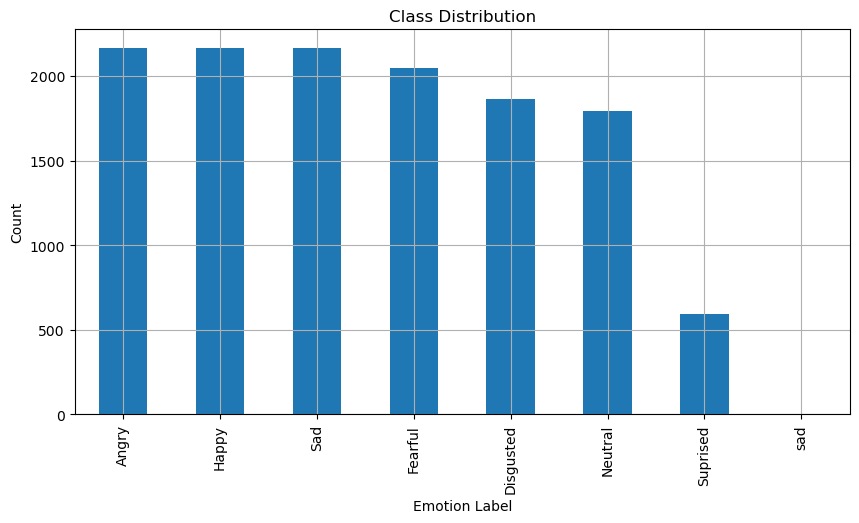

In [9]:
# Plot class distribution
label_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Emotion Label")
plt.ylabel("Count")
plt.show()

In [10]:
# Define feature columns
# We do not include row_id/IDs, s3 keys, or the label column to keep EDA focused on numeric features used for modeling.

id_cols = {"row_id", "s3_key_s", TARGET_COL}
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove ID like columns if present
feature_cols = [col for col in numeric_cols if col not in id_cols]

print("Number of numeric feature columns:", len(feature_cols))
print("Feature columns:", feature_cols[:15])

Number of numeric feature columns: 20
Feature columns: ['meanfreq', 'sd', 'median', 'q25', 'q75', 'iqr', 'skew', 'kurt', 'sp_ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun']


In [11]:
# Descriptive stats for numeric features
# Helps spot extreme values or need for scaling
df[feature_cols].describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
meanfreq,12803.0,2349.548859,1466.102652,0.000000,1340.077372,1640.562291,2937.567398,7655.335725
sd,12803.0,2448.857970,1105.331707,0.000000,1809.724607,1939.140794,2513.590906,6368.165164
median,12803.0,4592.871880,2693.268490,0.000000,2991.652716,3460.484601,5067.544878,14629.598497
q25,12803.0,0.090434,0.045660,0.000000,0.061983,0.078273,0.105006,0.315741
q75,12803.0,-404.811457,107.282114,-1131.371000,-436.814780,-384.585360,-340.746710,0.249978
iqr,12803.0,87.625927,25.626645,-4.715626,69.722527,93.540010,107.585965,169.425420
skew,12803.0,19.770458,22.122854,-53.822807,2.519434,23.961128,37.809208,63.422300
kurt,12803.0,17.881224,11.720197,-32.020836,10.731665,19.662273,26.285018,52.933296
sp_ent,12803.0,3.570897,10.368510,-42.616806,-2.869021,4.156478,10.469075,42.492943
sfm,12803.0,1.533210,7.317598,-24.397316,-3.399498,1.475151,6.332037,26.737692


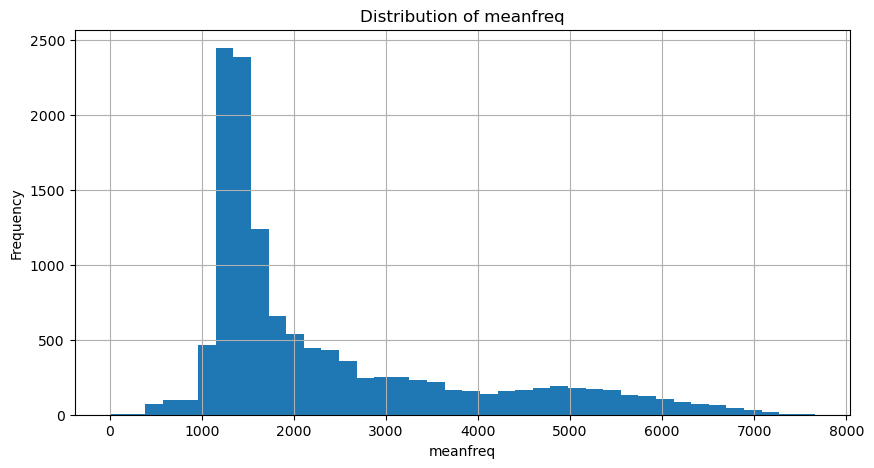

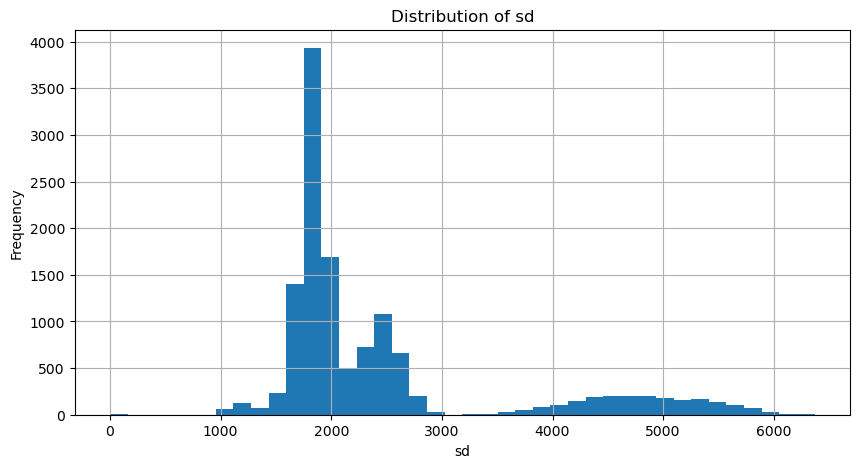

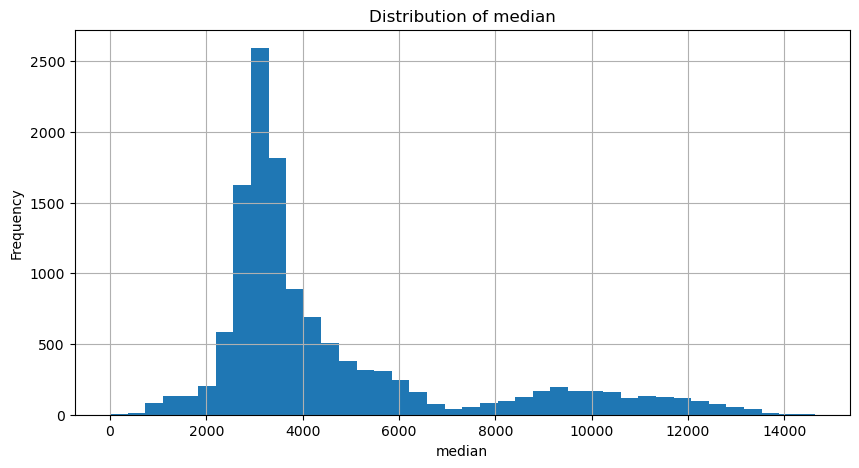

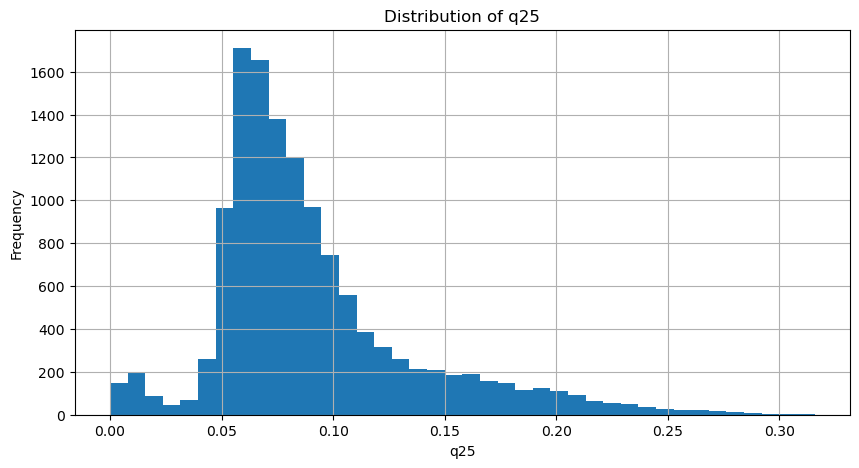

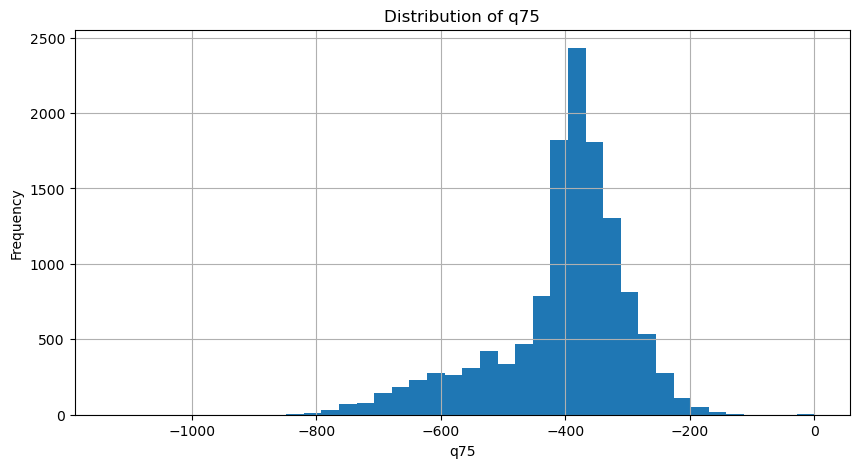

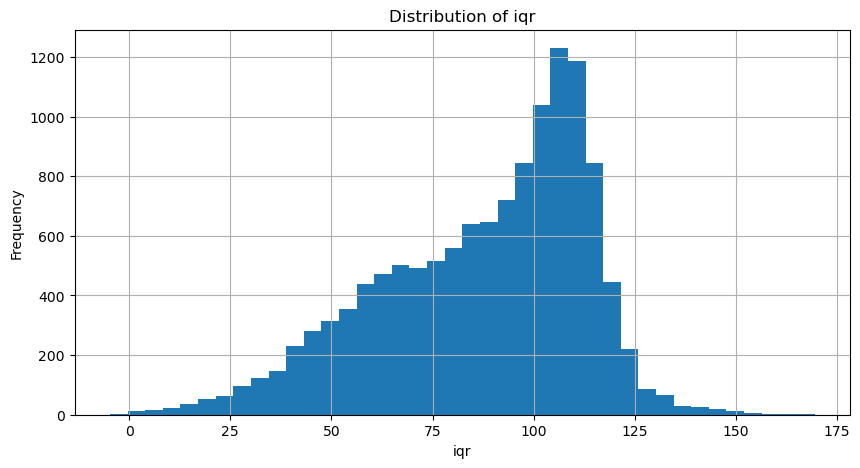

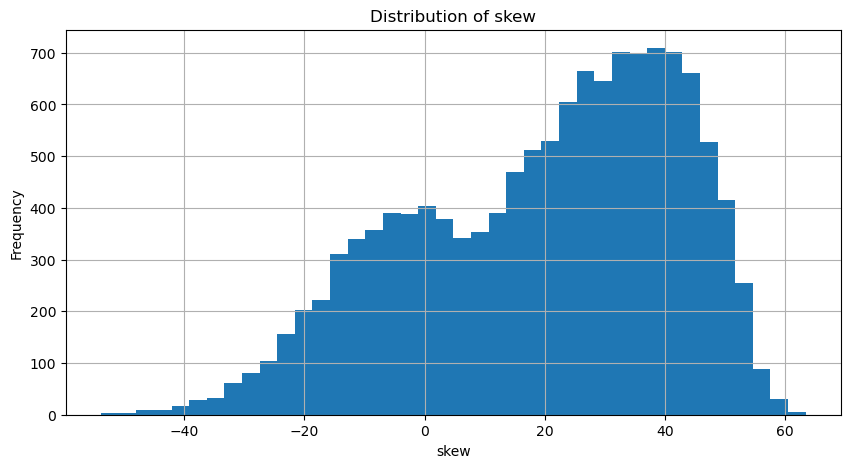

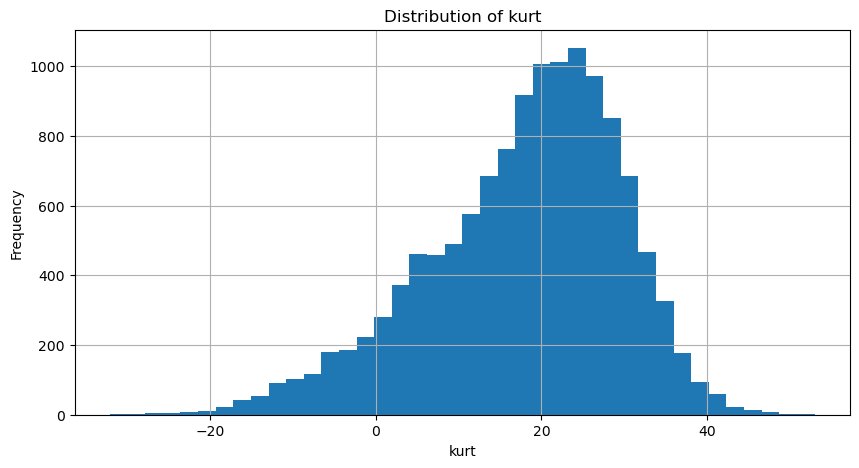

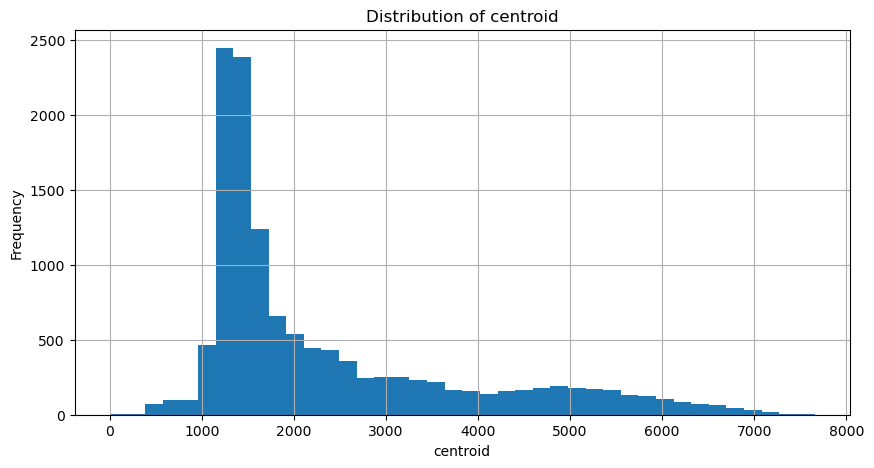

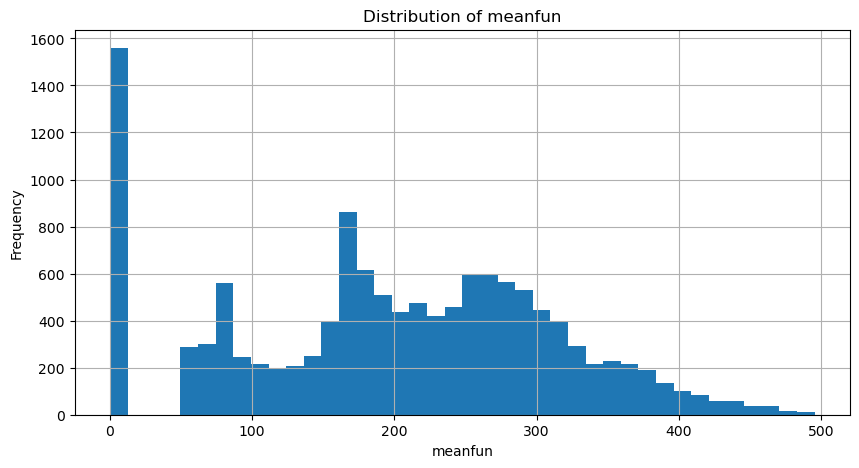

In [12]:
# Distribution plot of key features (just chose a few to plot)
plot_features = ['meanfreq', 'sd', 'median', 'q25', 'q75', 'iqr', 'skew', 'kurt', 'centroid', 'meanfun']
key_features = [c for c in plot_features if c in df.columns]

# Plot
for col in key_features:
  df[col].hist(bins=40)
  plt.title(f"Distribution of {col}")
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.show()

In [13]:
#Check for outliers (IQR based)
def outlier_rate_iqr(series: pd.Series) -> float:
  s = series.dropna()
  if s.empty:
    return np.nan
  q1, q3 = np.percentile(s, 25), np.percentile(s, 75)
  iqr = q3 - q1
  low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
  return float(((s < low ) | (s > high)).mean())

outlier_rates = {col: outlier_rate_iqr(df[col]) for col in key_features}
pd.Series(outlier_rates).sort_values(ascending=False)

sd          0.160197
median      0.142545
q75         0.095993
q25         0.077326
meanfreq    0.068500
centroid    0.068500
kurt        0.012731
iqr         0.004062
skew        0.000391
meanfun     0.000000
dtype: float64

No outliers detected.

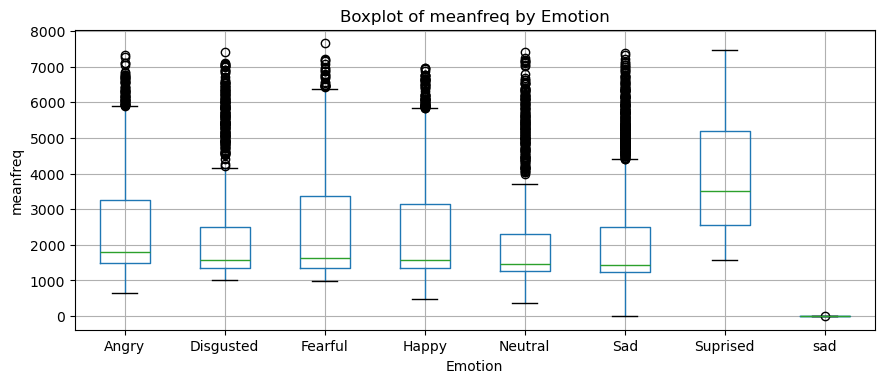

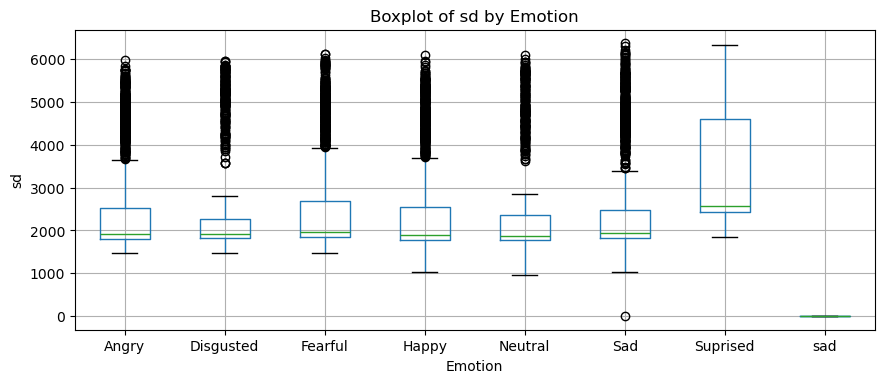

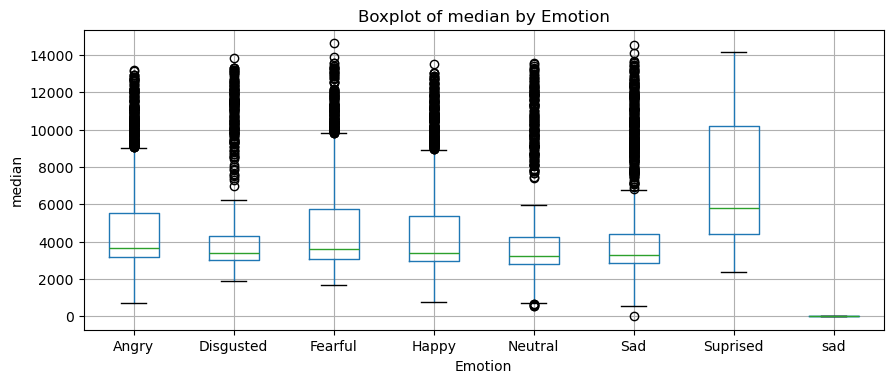

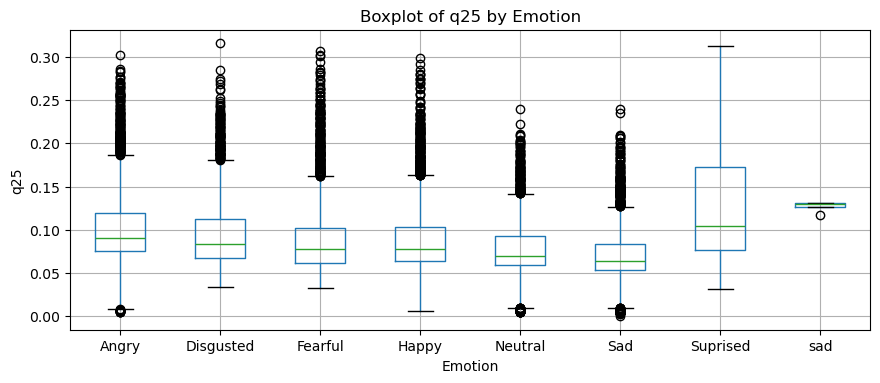

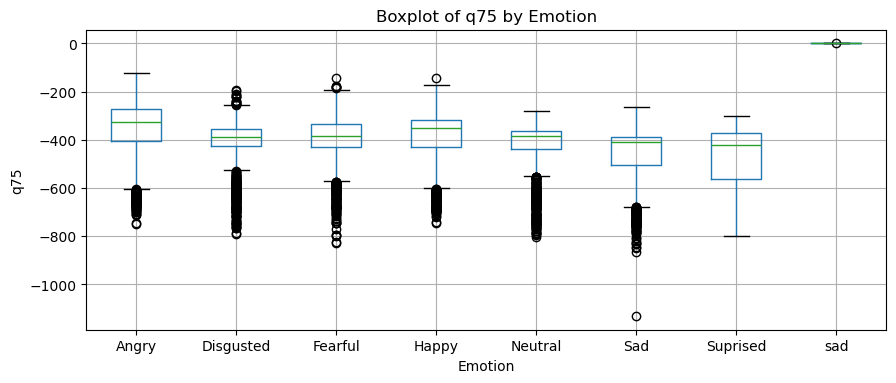

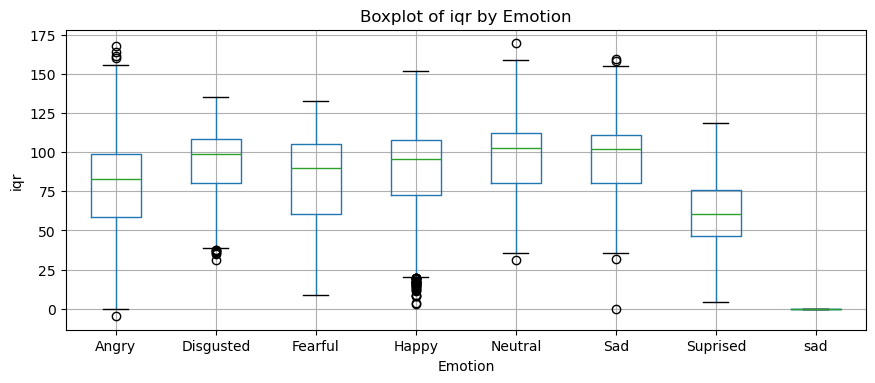

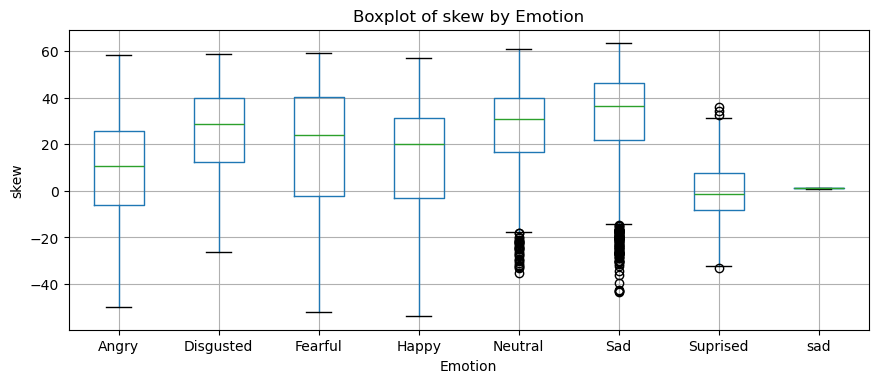

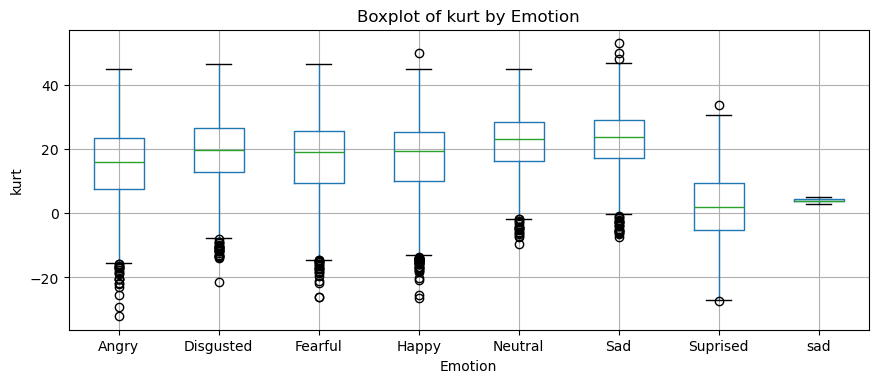

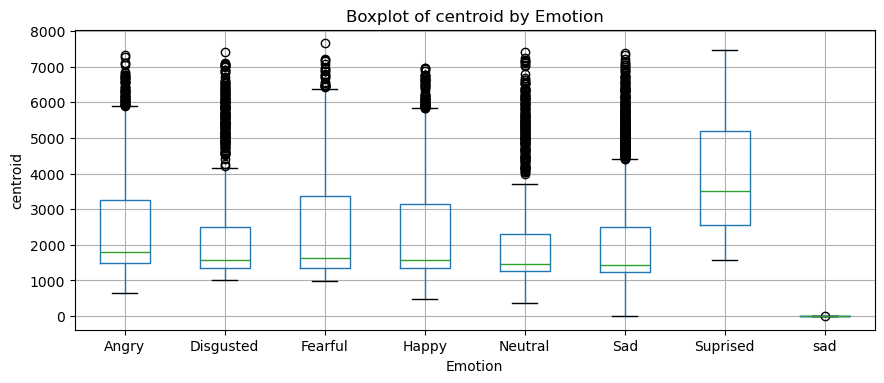

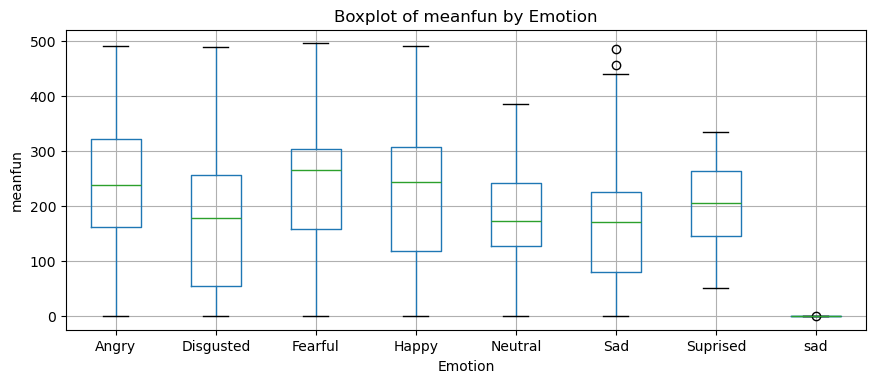

In [14]:
# Boxplot by emotion (no outliers detected, so show all points)
for col in key_features:
  df.boxplot(column=col, by=TARGET_COL, figsize=(10, 4))
  plt.title(f"Boxplot of {col} by Emotion")
  plt.suptitle("")
  plt.xlabel("Emotion")
  plt.ylabel(col)
  plt.show()

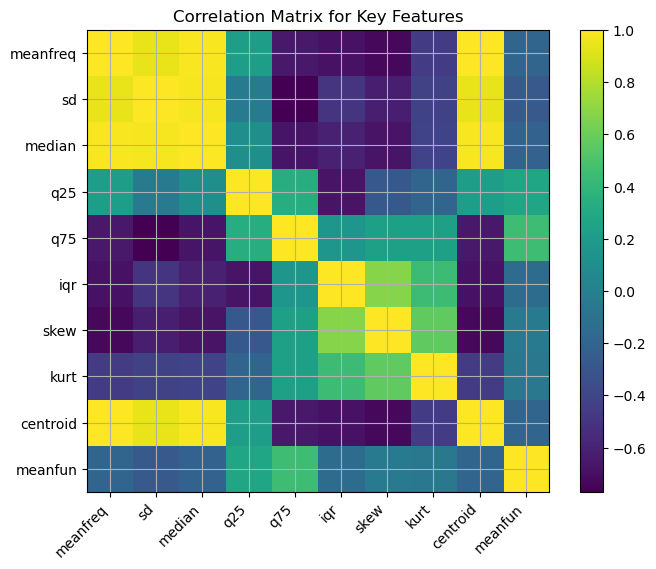

In [15]:
# Correlation analysis (compute on key features first because it is faster)
key_corr = df[key_features].corr()

plt.figure(figsize=(8, 6))
plt.imshow(key_corr, interpolation="nearest")
plt.xticks(range(len(key_features)), key_features, rotation=45, ha="right")
plt.yticks(range(len(key_features)), key_features)
plt.colorbar()
plt.title("Correlation Matrix for Key Features")
plt.show()

In [16]:
# Check the smallest class size
min_size = label_counts.min()
print("Smallest class count:", min_size)

Smallest class count: 5


We have 7 emotion classes, but one of them is underrepresented with only five samples.

# EDA Summary

### Emotion Class Distribution
The dataset includes 7 emotion classes (Angry, Happy, Neutral, Sad, Disgusted, Fearful, and Surprised), but the distribution is imbalanced. One emotion class contains 5 samples, making it underrepresented. This imbalance is important because relying soley on overall accuracy would mask poor performance on minority classes, so macro-averaged F1 score and per-class F1 are better evaluation metrics.

### Feature Distribution and Outlier
Histograms of key acoustic features (mean freq, spectral centroid, skewness, etc) show non-Gaussian and skewed distributions, with long tails in many frequency based features.
An IQR based outlier analysis found no outliers, suggesting that extreme values are part of natural variation in speech rather than data errors.

### Feature Behaviour Across Emotion Classes
Boxplots comparing acoustic features across emotion labels show consistent but overlapping difference between classes. Certain emotions portray higher central tendencies or variability in features such as mean frequency, spectral centroidm and energy related measures, suggesting that these features so capture emotion related patterns.

Additionally, there is a label inconsistency ('sad' vs 'Sad'), which should be fixed during preprocessing. Right now pandas is treating this emotion class as separate because one has a captial letter.

### Correlation Analysis
The correlation matrix shows that various frequency based features (such as mean, frequency, median, and spectral centroid) are highly correlated, suggesting that they capture similar information about audio. In contrast, variability related features (such as IQR, skewness, and kurtosis) form a separate group that describes the distribution and shape of the signal. Some features, like mean fundamental frequency, show weaker correlations and possibly add unique information.

### Limitations
The dataset contains acted emotional speech, which may not generalize well to real call-center conversations.

One class causing a class imbalance increases the risk of biased predictions.

#### Next Steps
Data Preprocessing:
- Fix labels (covert all labels to lowercase)
- Remove or merge the underrepresented class (5 samples)
- Apply feature scaling due to skewed feature distributions
